In [31]:
import jax 
import jax.numpy as jnp
from jax import random as jrd
import matplotlib.pyplot as plt
# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

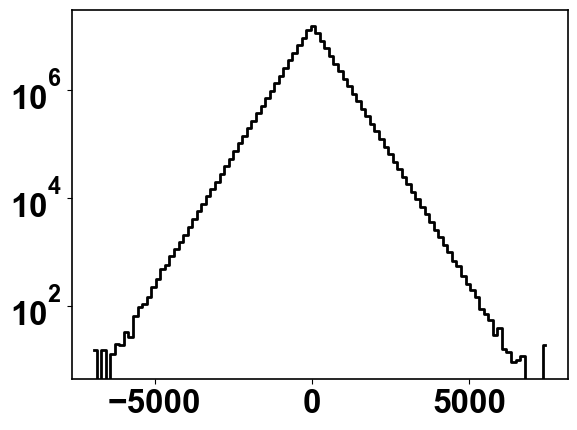

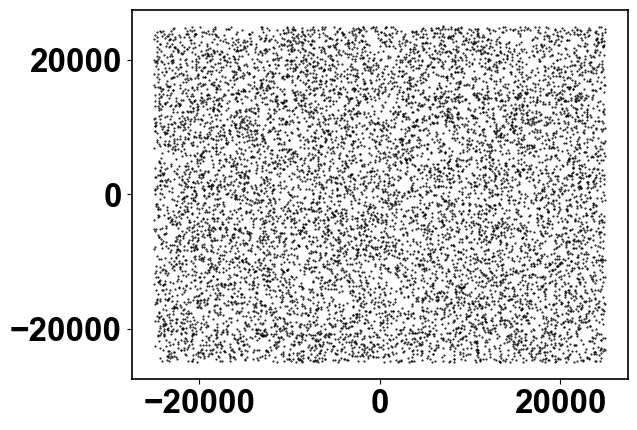

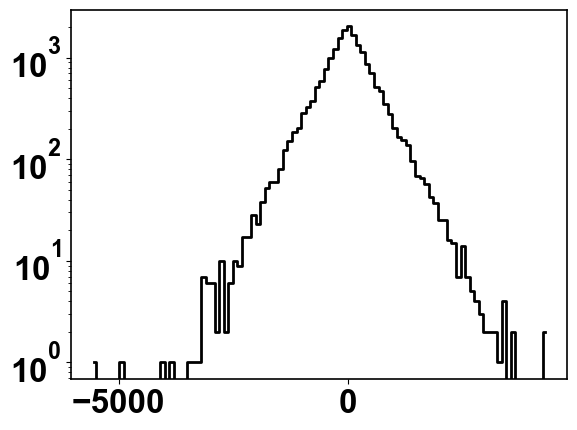

In [61]:
key = jrd.PRNGKey(99)
key, subkey = jrd.split(key)
z = jrd.laplace(subkey, shape=(100000000,))
z = z*450.
n, bins = jnp.histogram(z, bins=100)
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n, color='black', drawstyle='steps-mid', label='Laplace')
plt.yscale('log')
plt.show()
key, subkey = jrd.split(key)
x = jrd.uniform(subkey, shape=(100000000,), minval=-25000, maxval=25000)
key, subkey = jrd.split(key)
y = jrd.uniform(subkey, shape=(100000000,), minval=-25000, maxval=25000)
plt.scatter(x[::10000],y[::10000], s=1, color='black', marker='.')
plt.show()
r = jnp.sqrt(x**2 + y**2)
where = jnp.where(r<400)
n, bins = jnp.histogram(z[where], bins=100)
val= (bins[:-1] + bins[1:])/2
plt.plot(val, n, color='black', drawstyle='steps-mid', label='Laplace')
plt.yscale('log')
plt.show()


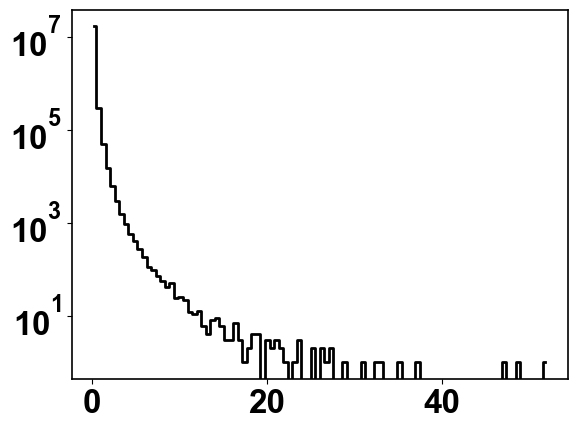

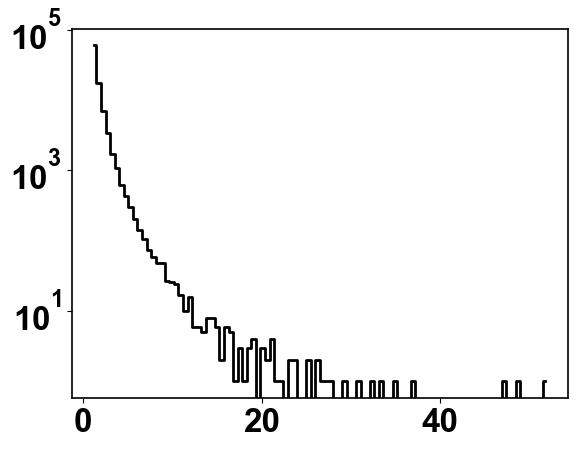

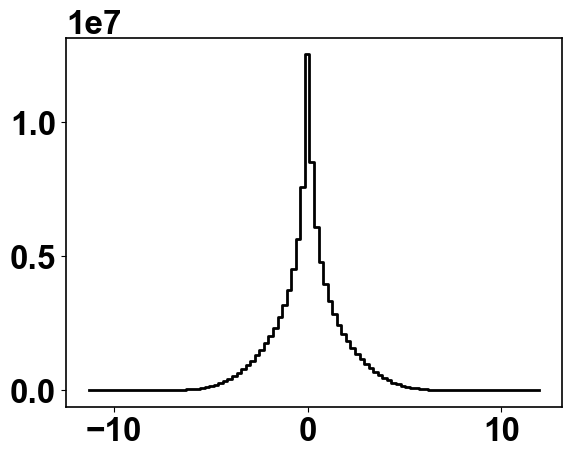

In [91]:
distance = jnp.sqrt(x**2 + y**2 + z**2)
b = jnp.arcsin(z/distance)
parallax = 1000./distance
n, bins = jnp.histogram(parallax, bins=100)
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n, color='black', drawstyle='steps-mid', label='Laplace')
plt.yscale('log')
plt.show()
where = jnp.where(parallax>1)
n, bins = jnp.histogram(parallax[where], bins=100)
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n, color='black', drawstyle='steps-mid', label='Laplace')
plt.yscale('log')
plt.show()
parallax_error = (0.01+0.4*distance/6000) * parallax * jrd.normal(subkey, shape=(100000000,)) #distance dependent (0.3 statt term gaußisch)
n, bins = jnp.histogram(parallax_error/parallax, bins=100)
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n, color='black', drawstyle='steps-mid', label='Laplace')
# plt.yscale('log')
plt.show()

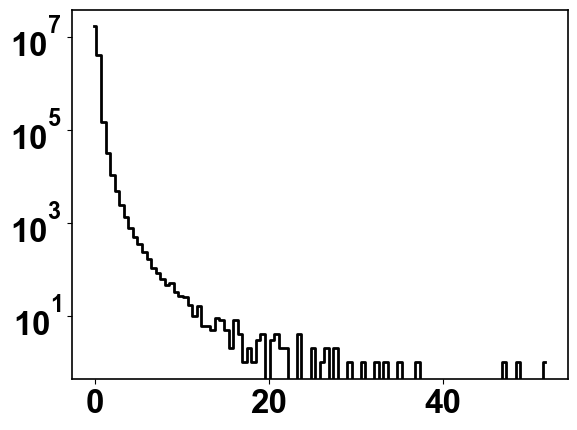

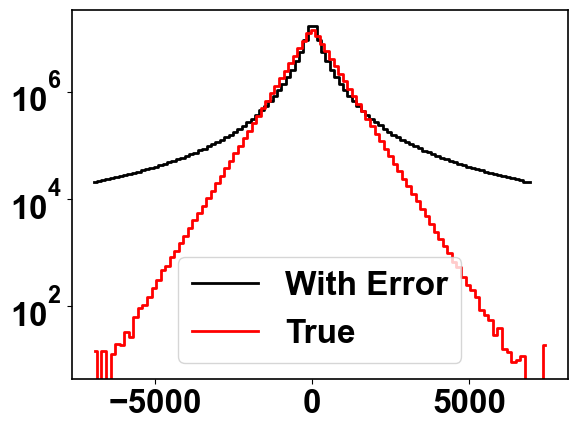

In [92]:
parallax_data = parallax + parallax_error
n, bins = jnp.histogram(parallax_data, bins=100)
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n, color='black', drawstyle='steps-mid', label='Laplace')
plt.yscale('log')
plt.show()
distance_data = 1000./parallax_data
r_data = distance_data * jnp.cos(b)
z_data = distance_data * jnp.sin(b)
where = jnp.where(abs(z_data)<7000)
z_data = z_data[where]
n, bins = jnp.histogram(z_data, bins=100)
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n, color='black', drawstyle='steps-mid', label='With Error')
n, bins = jnp.histogram(z, bins=100)
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n, color='red', drawstyle='steps-mid', label='True')
plt.yscale('log')
plt.legend()
plt.show()

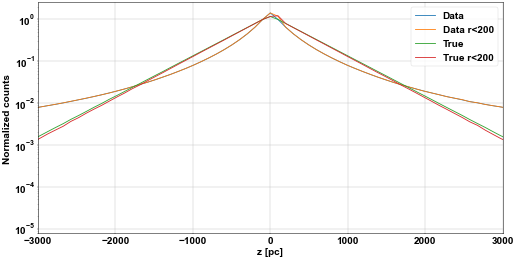

In [95]:
fig = plt.figure(figsize=(20,10))
n, bins = jnp.histogram(z_data, bins=101, range=(-5000, 5000))
val = (bins[:-1] + bins[1:])/2
plt.plot(val, n/n[int(len(n)/2)-1], label='Data')
where_ = jnp.where(r_data<200)
n_, bins_ = jnp.histogram(z_data[where_], bins=101, range=(-5000, 5000))
val_ = (bins_[:-1] + bins_[1:])/2
plt.plot(val_, n_/n_[int(len(n_)/2)-1], label='Data r<200')
n__, bins__ = jnp.histogram(z, bins=101, range=(-5000, 5000))
val__ = (bins__[:-1] + bins__[1:])/2
plt.plot(val__, n__/n__[int(len(n__)/2)-1], label='True')
n___, bins___ = jnp.histogram(z[where][where_], bins=101, range=(-5000, 5000))
val___ = (bins___[:-1] + bins___[1:])/2
plt.plot(val___, n___/n___[int(len(n___)/2)-1], label='True r<200')

plt.xlabel('z [pc]')
plt.ylabel('Normalized counts')
plt.yscale('log')
plt.xlim(-3000, 3000)
plt.legend()
plt.grid()
fig.set_dpi(30)
plt.show()